In [1]:
# load all required packages
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
import datetime as dt

First of, I convert the date column to a datetime data type and extract also the year, week and the "simple" date without the exact specification in terms of hours and minutes when the post was created. I check how many unique users are present and of how many posts the data consists.

In [2]:
# read in all the retrieved posts
posts_df = pd.read_csv("../01_data/clean_data/all_posts_cleaned.csv")

# create proper date columns
posts_df["date"] = pd.to_datetime(posts_df["date"], utc=True, format="mixed", errors="raise")
posts_df["year"] = posts_df["date"].dt.isocalendar().year
posts_df["week"] = posts_df["date"].dt.isocalendar().week
posts_df["simple_date"] = posts_df["date"].dt.date
posts_df['year_week'] = posts_df['year'].astype(str) + '-W' + posts_df['week'].astype(str).str.zfill(2)

# print number of different users and overall number of posts
print(f"Number of different users posting over the whole timeframe: {len(set(posts_df["clean_handle"]))}")
print(f"Number of overall posts: {len(posts_df)}")

Number of different users posting over the whole timeframe: 162
Number of overall posts: 18256


I count the number of posts per day (for all politicians from all parties) and plot these counts as a time series. In this figure I also highlight when the new election has been announced, the election day and when the new parliament has been constituted.

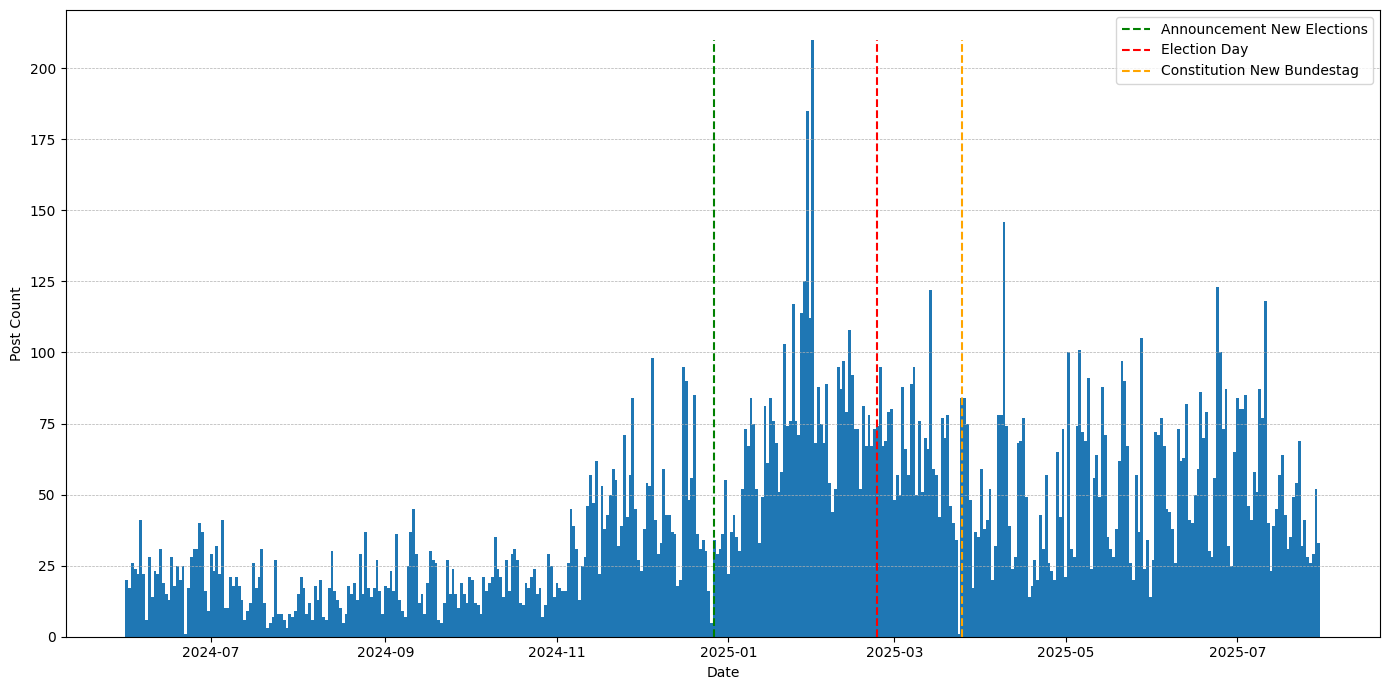

In [9]:
# count the number of posts per day
group_df = posts_df.groupby("simple_date").size().reset_index(name="count")
group_df.head()

# visualize the number of messages over time
plt.figure(figsize=(14, 7))
plt.bar(group_df["simple_date"], group_df["count"], width=1)
#plt.title("Number of Messages Over Time")
plt.xlabel("Date")
plt.ylabel("Post Count")
plt.vlines(dt.datetime(2024, 12, 27), ymin=0, ymax=max(group_df["count"]), colors="green", linestyles="--", label="Announcement New Elections")
plt.vlines(dt.datetime(2025, 2, 23), ymin=0, ymax=max(group_df["count"]), colors="red", linestyles="--", label="Election Day")
plt.vlines(dt.datetime(2025, 3, 25), ymin=0, ymax=max(group_df["count"]), colors="orange", linestyles="--", label="Constitution New Bundestag")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=.5)
plt.legend()
plt.savefig("../02_figures_tables/posts_per_day.png", dpi=300)
plt.show()

Next, I read in the dataframe that contains the sentiment scores and limit this dataframe to only those politicians that are in the parties of the analysis. Then I group by week and calculate the mean sentiment score in this week across all politicians as well as the standard error and confidence interval. This leads to a trajectory of the weekly mean sentiment score which is plotted underneath.

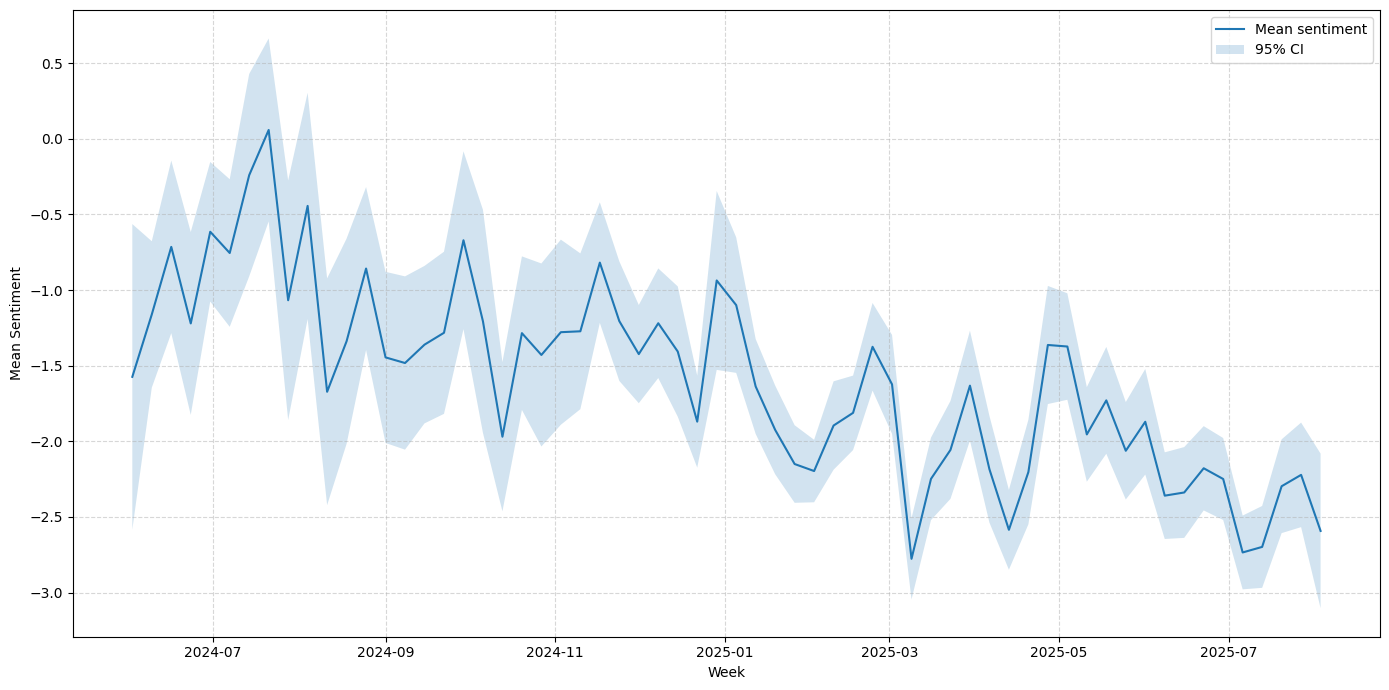

In [53]:
# read in all labelled posts
labelled_posts_df = pd.read_csv("../01_data/clean_labelled_data/all_posts_cleaned_labelled.csv")

# limit to the parties of the analysis
labelled_posts_df = labelled_posts_df[labelled_posts_df["faction"].isin(["SPD", "Grünen", "Die LINKE"])]

# group by week and calculate mean sentiment as well as sd
labelled_posts_df["date"] = pd.to_datetime(labelled_posts_df["date"])
weekly_sentiments = labelled_posts_df.groupby(pd.Grouper(key="date", freq="W"))["sentiment_score"].agg(["mean", "std", "count"]).reset_index()

# calculate standard error of mean estimates and get confidence intervals based on these
weekly_sentiments["se"] = weekly_sentiments["std"] / weekly_sentiments["count"]**0.5
weekly_sentiments["ci95_lower"] = weekly_sentiments["mean"] - 1.96 * weekly_sentiments["se"]
weekly_sentiments["ci95_upper"] = weekly_sentiments["mean"] + 1.96 * weekly_sentiments["se"]

# create plot outline for two plots
plt.figure(figsize=(14, 7))

# create lineplot for mean sentiment over time
plt.plot(weekly_sentiments["date"], weekly_sentiments["mean"], label="Mean sentiment")
plt.fill_between(
    weekly_sentiments["date"],
    weekly_sentiments["ci95_lower"],
    weekly_sentiments["ci95_upper"],
    alpha=0.2,
    label="95% CI"
)
plt.xlabel("Week")
plt.ylabel("Mean Sentiment")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../02_figures_tables/mean_sentiment_per_time.png", dpi=300)
plt.show()